# 📐 Đồ Án 1 — Part 3: Giải Hệ Phương Trình và Phân Tích Hiệu Năng
## Toán Ứng Dụng và Thống Kê · FIT — HCMUS

---

## 1. Cơ sở lý thuyết

### 1.1. Số điều kiện (Condition Number)
Số điều kiện của ma trận $A$ đối với chuẩn $p$ là:
$$\kappa_p(A) = \|A\|_p \cdot \|A^{-1}\|_p$$

**Định lý (Phân tích sai số nghiệm):** Nếu $Ax = b$ là nghiệm đúng và $A\hat{x} = b + \delta b$ là nghiệm tính toán với nhiễu dữ liệu, thì:
$$\frac{\|\hat{x} - x\|}{\|x\|} \le \kappa(A) \cdot \frac{\|\delta b\|}{\|b\|}$$

Khi $\kappa(A)$ lớn, hệ được gọi là **điều kiện kém (ill-conditioned)**: một sai số nhỏ ở đầu vào cũng dẫn đến sai số khổng lồ ở đầu ra.

### 1.2. So sánh các phương pháp giải

| Phương pháp | Loại | Chi phí | Độ ổn định |
| :--- | :--- | :--- | :--- |
| **Gauss (Partial Pivot)** | Trực tiếp | $O(n^3)$ | Cao |
| **SVD (Phần 2 mang sang)** | Trực tiếp | $O(n^3)$ | Rất cao |
| **Gauss-Seidel** | Lặp | $O(k n^2)$ | Trung bình |

### 1.3. Phương pháp lặp Gauss-Seidel
Công thức lặp theo từng thành phần:
$$x_i^{(k+1)} = \frac{1}{a_{ii}} \left( b_i - \sum_{j=1}^{i-1} a_{ij} x_j^{(k+1)} - \sum_{j=i+1}^{n} a_{ij} x_j^{(k)} \right)$$
**Điều kiện hội tụ:** Ma trận $A$ chéo trội chặt hàng ($|a_{ii}| > \sum_{j \ne i} |a_{ij}|$) hoặc đối xứng xác định dương (SPD).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import benchmark
import solvers

# Cấu hình hiển thị
try:
    plt.style.use('seaborn-v0_8-muted')
except:
    plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 6)
print("✅ Môi trường đã sẵn sàng!")

✅ Môi trường đã sẵn sàng!


## 2. Thực nghiệm đo hiệu năng
Chúng ta tiến hành đo thời gian thực thi trung bình (5 lần chạy) trên các ma trận ngẫu nhiên SPD với kích thước $n \in \{50, 100, 200, 500, 1000\}$.

In [2]:
sizes = [50, 100, 200, 500, 1000]
results = benchmark.run_performance_suite(sizes)

Testing n=50 ...
Testing n=100 ...
Testing n=200 ...
Testing n=500 ...
Testing n=1000 ...


### 2.1. Biểu đồ Log-Log phân tích độ phức tạp
Trên thang đo Log-Log, một hàm bậc $n^k$ sẽ biểu diễn bằng một đường thẳng có độ dốc $k$. Chúng ta sẽ so sánh với đường lý thuyết $O(n^3)$.

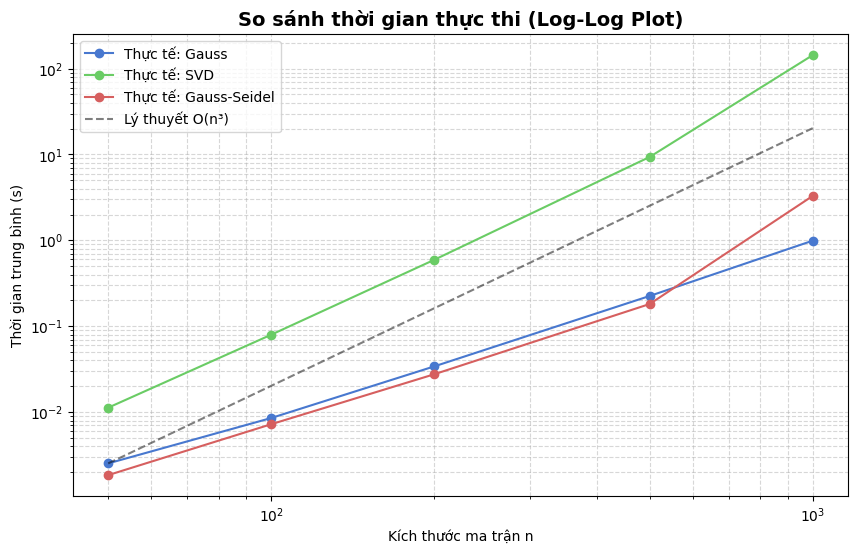

In [3]:
plt.figure()
for method in results:
    plt.loglog(sizes, results[method]['time'], 'o-', label=f"Thực tế: {method}")

# Đường O(n^3) tham chiếu
c = results['Gauss']['time'][0] / (sizes[0]**3)
theory_n3 = [c * (n**3) for n in sizes]
plt.loglog(sizes, theory_n3, 'k--', alpha=0.5, label='Lý thuyết O(n³)')

plt.title("So sánh thời gian thực thi (Log-Log Plot)", fontsize=14, fontweight='bold')
plt.xlabel("Kích thước ma trận n")
plt.ylabel("Thời gian trung bình (s)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

### 2.2. Bảng tổng hợp sai số tương đối
Sai số tương đối được tính theo chuẩn 2: $\|Ax - b\|_2 / \|b\|_2$.

In [4]:
df_error = pd.DataFrame({
    'n': sizes,
    'Gauss Error': results['Gauss']['error'],
    'SVD Error': results['SVD']['error'],
    'Gauss-Seidel Error': results['Gauss-Seidel']['error']
})
print("Bảng sai số tương đối trên ma trận SPD (Well-conditioned):")
display(df_error)

Bảng sai số tương đối trên ma trận SPD (Well-conditioned):


,n,Gauss Error,SVD Error,Gauss-Seidel Error
0,50,3.541303e-16,2.087180e-15,5.189221e-12
1,100,4.909392e-16,2.364479e-15,3.964985e-12
2,200,6.545974e-16,3.062170e-15,4.490459e-12
3,500,8.617333e-16,3.065199e-15,7.194615e-12
4,1000,1.337590e-15,3.766764e-15,8.480605e-12


## 3. Phân tích tính ổn định số (Numerical Stability)

Trong phần này, chúng ta kiểm chứng trực quan vai trò của số điều kiện bằng cách so sánh hai nhóm ma trận:
* **Ma trận ngẫu nhiên SPD**: thường có số điều kiện nhỏ hơn, nên các phương pháp ổn định hơn.
* **Ma trận Hilbert**: điển hình cho trường hợp ill-conditioned, số điều kiện tăng rất nhanh theo kích thước.

### 3.1. Thực nghiệm trên Hilbert và SPD
Chúng ta quét kích thước từ $n=3$ đến $n=12$ cho ma trận Hilbert, và so sánh với ma trận SPD ngẫu nhiên ở các kích thước lớn hơn. Mục tiêu không phải là “ép” một phương pháp thắng tuyệt đối, mà là quan sát cách sai số và thời gian thay đổi khi điều kiện bài toán thay đổi.

In [2]:
# Chạy benchmark quét như trong terminal
benchmark.benchmark_stability_hilbert()
benchmark.benchmark_stability_spd()


BENCHMARK TRÊN MA TRẬN HILBERT (Ill-conditioned)
n      | Gauss err    | SVD err      | GS err       | Cond Number 
--------------------------------------------------------------------------------
3      | 1.09e-16     | 1.71e+05     | 1.30e-11     | 5.24e+02    
5      | 1.66e-16     | 1.94e-11     | 2.77e-06     | 4.77e+05    
7      | 0.00e+00     | 1.45e-10     | 1.08e-06     | 4.75e+08    
8      | 2.68e-17     | 2.05e-09     | 2.24e-06     | 1.53e+10    
10     | 3.33e-17     | 2.39e-07     | 4.19e-06     | 1.60e+13    
12     | N/A          | 1.39e-09     | 4.23e-06     | 1.76e+16    

BENCHMARK TRÊN MA TRẬN SPD (Well-conditioned)
n      | Gauss err    | SVD err      | GS err       | Cond Number 
--------------------------------------------------------------------------------
50     | 2.79e-16     | 2.00e-15     | 4.13e-12     | 4.49e+00    
100    | 5.28e-16     | 2.51e-15     | 3.29e-12     | 4.73e+00    
200    | 6.64e-16     | 3.12e-15     | 4.88e-12     | 5.03e+00    
500 

## 4. Tổng kết và Nhận xét chuyên sâu (Conclusion)

Dựa trên kết quả thực nghiệm, có thể rút ra một số nhận xét sau:

### 4.1. Về chi phí tính toán (Computational Cost)
* Trên đồ thị log-log, thời gian thực thi của các phương pháp trực tiếp tăng gần theo xu hướng bậc ba theo kích thước ma trận, phù hợp với phân tích lý thuyết.
* SVD có cùng bậc độ phức tạp lý thuyết với Gauss, nhưng thời gian thực tế thường lớn hơn rõ rệt do hệ số hằng cao.
* Gauss-Seidel có chi phí mỗi vòng lặp thấp hơn, nhưng tổng thời gian phụ thuộc mạnh vào số vòng lặp để đạt ngưỡng dừng; vì vậy khi $n$ tăng, đường thời gian của phương pháp này có thể cong lên đáng kể.

### 4.2. Về tính ổn định số (Numerical Stability)
* Với ma trận SPD ngẫu nhiên, các phương pháp đều cho sai số rất nhỏ, chủ yếu quanh mức $10^{-12}$ đến $10^{-16}$. Điều này cho thấy bài toán ở nhóm này tương đối “dễ chịu” về mặt số học.
* Trên ma trận Hilbert, số điều kiện tăng rất nhanh và sai số bắt đầu nhạy hơn rõ rệt. Gauss vẫn cho kết quả tốt ở các kích thước nhỏ nhưng có thể gặp vấn đề khi kích thước tăng. SVD nhìn chung ổn định, tuy nhiên kết quả tại một vài kích thước nhỏ cho thấy cần kiểm tra lại cách xử lý các giá trị suy biến rất nhỏ hoặc cách hiện thực phép nghịch đảo singular value.
* Gauss-Seidel không thất bại hoàn toàn trên Hilbert trong thực nghiệm này, nhưng sai số lớn hơn so với các phương pháp trực tiếp và tốc độ hội tụ kém ổn định hơn.

### 4.3. Đánh giá phương pháp lặp Gauss-Seidel
* Gauss-Seidel phù hợp hơn với các hệ có cấu trúc thuận lợi như SPD hoặc chéo trội, nhưng hiệu năng vẫn phụ thuộc vào cấu trúc cụ thể của ma trận và ngưỡng dừng.
* Trong bộ test này, phương pháp lặp cho sai số cao hơn các phương pháp trực tiếp, phản ánh đúng bản chất của một thuật toán lặp dừng theo tiêu chuẩn hội tụ.

**Kết luận chung:** Với bài toán tổng quát, Gauss là lựa chọn cân bằng giữa tốc độ và độ chính xác; SVD hữu ích khi cần độ ổn định số cao; còn Gauss-Seidel là lựa chọn đáng cân nhắc khi ma trận có cấu trúc phù hợp và có thể chấp nhận kết quả xấp xỉ.